In [1]:
#all packages needed 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import umap
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import joblib
import shap

#CNN modules
from tensorflow.keras.layers import Conv1D, MaxPooling1D
#setting seed for reproducibility
import random
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
set_seed(42)
scale=StandardScaler()

2026-05-29 14:07:42.753235: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def bootstrap_f1(y_pred, y_test):
    #boot strapping for f1 score
    bootstrap_s=1000
    length=len(y_pred)
    f1_list=[]
    rng=np.random.RandomState(42)
    for _ in range(bootstrap_s):
        indices=resample(range(length), replace=True, random_state=rng)
        # skip invalid bootstrap samples
        if len(np.unique(y_test[indices])) < 2:
            continue
        f1_boots=classification_report(y_test[indices], y_pred[indices], output_dict=True)['macro avg']['f1-score']
        f1_list.append(f1_boots)
    

    f1_list=np.array(f1_list)
    print("F1-score 95% confidence intervals: ", np.percentile(f1_list, 2.5), " - ", np.percentile(f1_list, 97.5), " and a mean of: ", f1_list.mean())

In [3]:
#importing the gridsearch table with the chosen parammeters

df_modelling=pd.read_parquet('../df_modelling.parquet')

Preparing Dataset for deep models (LSTM and CNN-LSTM)

In [4]:
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days'],
      dtype='object')


In [5]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [6]:
sequence_length = 20  # timesteps

#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# TRAIN
emb_train_raw = embeddings_array[:train_end]
num_train_raw = numerical_values[:train_end]
y_train_raw   = y[:train_end]

# VALIDATION
emb_val_raw = embeddings_array[train_end-sequence_length:val_end]
num_val_raw = numerical_values[train_end-sequence_length:val_end]
y_val_raw   = y[train_end-sequence_length:val_end]

# TEST
emb_test_raw = embeddings_array[val_end-sequence_length:]
num_test_raw = numerical_values[val_end-sequence_length:]
y_test_raw   = y[val_end-sequence_length:]

num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)

In [7]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

BEST Model: CNN+LSTM F1->64%

In [8]:
model = load_model("best_model_CNN-LSTM.keras")
print("CNN-LSTM's architecture: ", model.summary())
print("Learning Rate:", model.optimizer.learning_rate.numpy())
print("Optimizer: ", type(model.optimizer).__name__)
for layer in model.layers:
    config = layer.get_config()
    
    if 'dropout' in config or 'recurrent_dropout' in config:
        print(layer.name)
        print("dropout:", config.get('dropout'))
        print("recurrent_dropout:", config.get('recurrent_dropout'))
        print()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 20, 128)   │    196,736 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 10, 128)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 10, 32)    │     20,608 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 16)        │      3,136 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 8)         │        480 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 24)        │          0 │ lstm_4[0][0],     │
│ (Concatenate)       │                   │            │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         25 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 662,957 (2.53 MB)

 Trainable params: 220,985 (863.22 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 441,972 (1.69 MB)

CNN-LSTM's architecture:  None
Learning Rate: 0.001
Optimizer:  Adam
lstm_3
dropout: 0.0
recurrent_dropout: 0.0

lstm_4
dropout: 0.0
recurrent_dropout: 0.0

lstm_5
dropout: 0.0
recurrent_dropout: 0.0



In [9]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']["f1-score"]
print(f"Best Result is f1 {f1} at threshold {threshold}")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_2', 'input_layer_3']. Received: the structure of inputs=('*', '*')
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Best Result is f1 0.6435601198117245 at threshold 0.6000000000000001


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.57      0.60      0.59        20
           1       0.71      0.69      0.70        29

    accuracy                           0.65        49
   macro avg       0.64      0.64      0.64        49
weighted avg       0.66      0.65      0.65        49

confusion_matrix is:


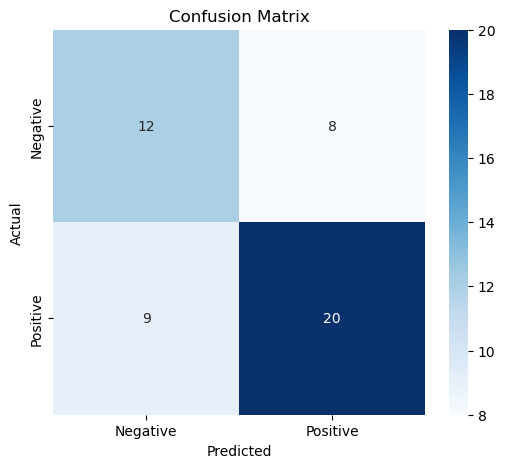

In [10]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix CNN-LSTM.png", bbox_inches='tight', transparent=True)
plt.show()

In [11]:
#bootstrapping F1-score
bootstrap_f1(y_pred, y_test)

F1-score 95% confidence intervals:  0.49982758620689655  -  0.7740041928721174  and a mean of:  0.6378378251262271


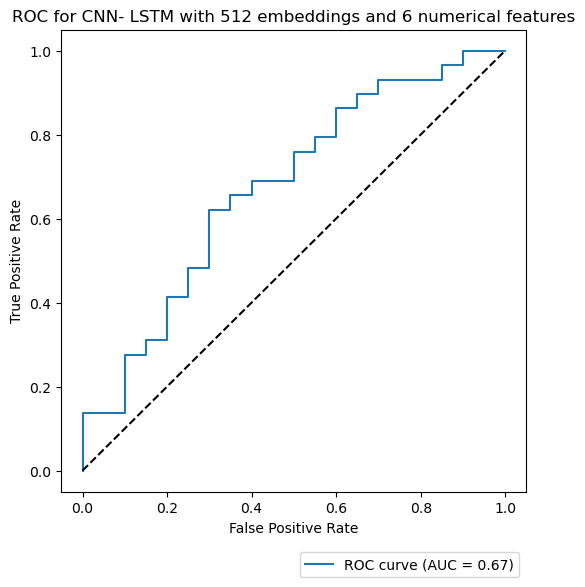

In [12]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.title("ROC for CNN- LSTM with 512 embeddings and 6 numerical features")
plt.show()

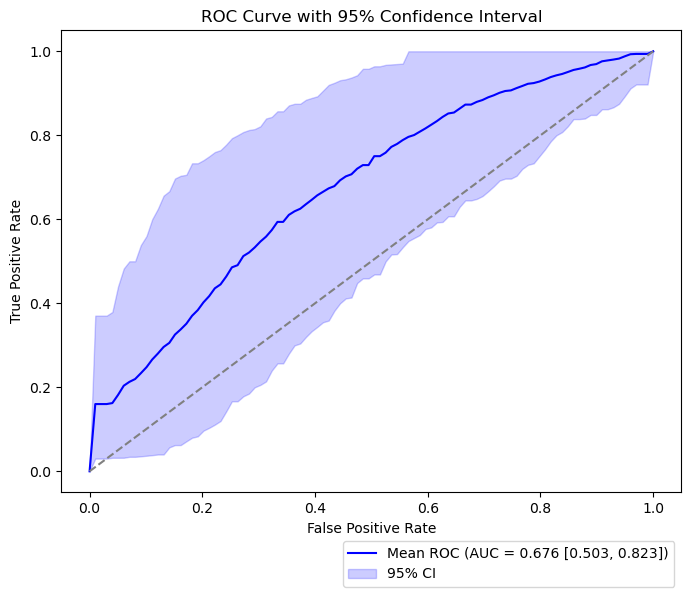

In [13]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.22), facecolor='none')
plt.savefig("Results/ROC curve CNN-LSTM.png", bbox_inches='tight', transparent=True)
plt.show()

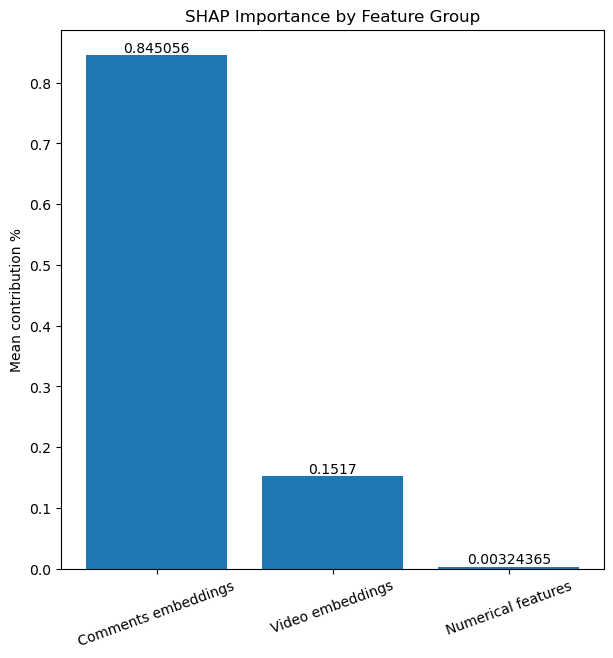

In [14]:
# Create SHAP explainer

# 1. background data with first 100 samples
background = [
    X_emb_train[:100],   
    X_num_train[:100]   
]
# 2. create DeepExplainer
explainer = shap.GradientExplainer(model, background)



# 3. compute SHAP values
shap_values = explainer.shap_values([
    X_emb_test,
    X_num_test
])

# 4. split model inputs
shap_emb = shap_values[0]   # embeddings branch
shap_num = shap_values[1]   # numerical branch

# 5. split embeddings into comment vs text
shap_comment = shap_emb[:, :, :256]
shap_text    = shap_emb[:, :, 256:]

# 6. aggregate over time + features (for interpretability)
comment_importance = np.abs(shap_comment).sum(axis=(1, 2))
text_importance    = np.abs(shap_text).sum(axis=(1, 2))
num_importance     = np.abs(shap_num).sum(axis=(1, 2))


#visualisation

labels = ["Comments embeddings", "Video embeddings", "Numerical features"]
total=(comment_importance.mean() + text_importance.mean() + num_importance.mean())

values = [
    comment_importance.mean()/total,
    text_importance.mean()/total,
    num_importance.mean()/total
]

fig, ax = plt.subplots(figsize=(7,7))
bars=plt.bar(labels, values)
ax.bar_label(bars)
plt.title("SHAP Importance by Feature Group")
plt.ylabel("Mean contribution %")
plt.xticks(rotation=20)
plt.savefig("Results/Feature Importance CNN-LSTM.png",transparent=True)
plt.show()

3rd Best Model -> LSTM F1 -> 53%

In [15]:
model = load_model("best_model_LSTM.keras")
print("LSTM's architecture: ", model.summary())
print("Learning Rate:", model.optimizer.learning_rate.numpy())
print("Optimizer: ", type(model.optimizer).__name__)
for layer in model.layers:
    config = layer.get_config()
    
    if 'dropout' in config or 'recurrent_dropout' in config:
        print(layer.name)
        print("dropout:", config.get('dropout'))
        print("recurrent_dropout:", config.get('recurrent_dropout'))
        print()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 20, 64)    │    147,712 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 20, 16)    │      1,472 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 32)        │     12,416 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 8)         │        800 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 40)        │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         41 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 487,325 (1.86 MB)

 Trainable params: 162,441 (634.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 324,884 (1.24 MB)

LSTM's architecture:  None
Learning Rate: 0.001
Optimizer:  Adam
lstm_4
dropout: 0.0
recurrent_dropout: 0.0

lstm_6
dropout: 0.0
recurrent_dropout: 0.0

lstm_5
dropout: 0.0
recurrent_dropout: 0.0

lstm_7
dropout: 0.0
recurrent_dropout: 0.0



In [16]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_2', 'input_layer_3']. Received: the structure of inputs=('*', '*')
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Best Result is f1 0.5306122448979592 at threshold 0.7000000000000001


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.45      0.65      0.53        20
           1       0.65      0.45      0.53        29

    accuracy                           0.53        49
   macro avg       0.55      0.55      0.53        49
weighted avg       0.57      0.53      0.53        49

confusion_matrix is:


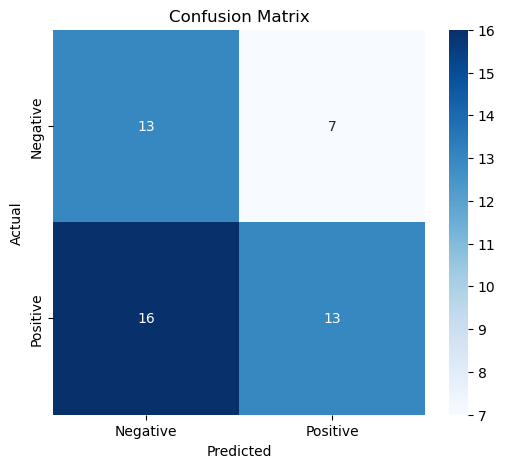

In [17]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix LSTM.png", transparent=True)
plt.show()

In [18]:
#bootstrapping F1-score
bootstrap_f1(y_pred, y_test)

F1-score 95% confidence intervals:  0.38545150501672243  -  0.67003367003367  and a mean of:  0.5258382566679354


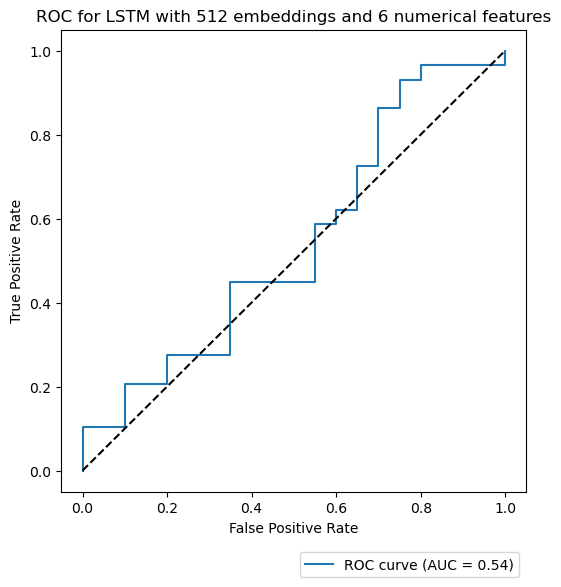

In [19]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.title("ROC for LSTM with 512 embeddings and 6 numerical features")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.show()

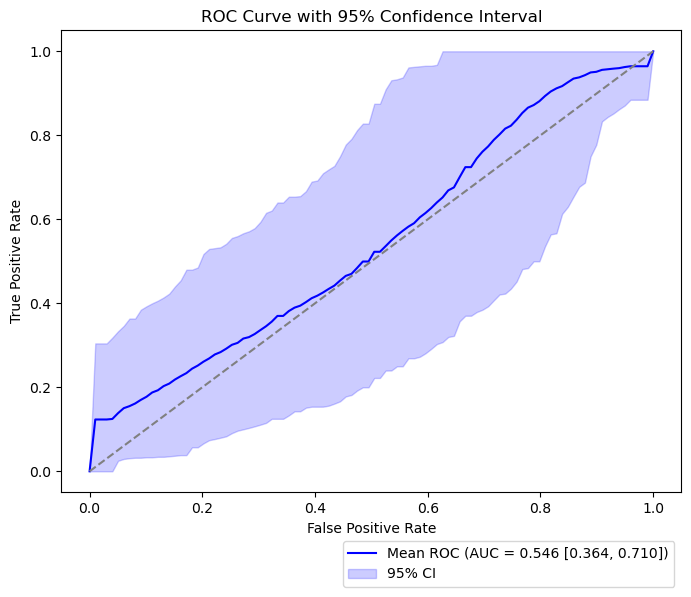

In [20]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.22), facecolor='none')
plt.savefig("Results/ROC curve LSTM.png", bbox_inches='tight', transparent=True)
plt.show()

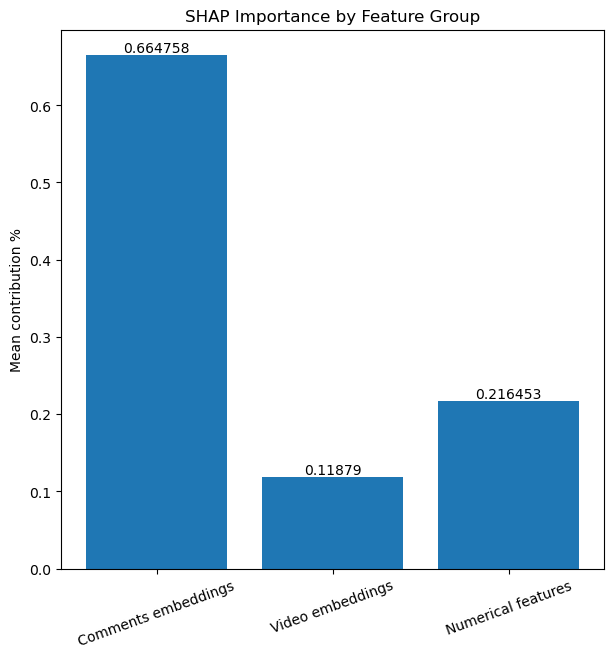

In [21]:
# Create SHAP explainer

# 1. background data with first 100 samples
background = [
    X_emb_train[:100],   
    X_num_train[:100]   
]
# 2. create DeepExplainer
explainer = shap.GradientExplainer(model, background)



# 3. compute SHAP values
shap_values = explainer.shap_values([
    X_emb_test,
    X_num_test
])

# 4. split model inputs
shap_emb = shap_values[0]   # embeddings branch
shap_num = shap_values[1]   # numerical branch

# 5. split embeddings into comment vs text
shap_comment = shap_emb[:, :, :256]
shap_text    = shap_emb[:, :, 256:]

# 6. aggregate over time + features (for interpretability)
comment_importance = np.abs(shap_comment).sum(axis=(1, 2))
text_importance    = np.abs(shap_text).sum(axis=(1, 2))
num_importance     = np.abs(shap_num).sum(axis=(1, 2))


#visualisation

labels = ["Comments embeddings", "Video embeddings", "Numerical features"]
total=(comment_importance.mean() + text_importance.mean() + num_importance.mean())

values = [
    comment_importance.mean()/total,
    text_importance.mean()/total,
    num_importance.mean()/total
]

fig, ax = plt.subplots(figsize=(7,7))
bars=plt.bar(labels, values)
ax.bar_label(bars)
plt.title("SHAP Importance by Feature Group")
plt.ylabel("Mean contribution %")
plt.xticks(rotation=20)
plt.savefig("Results/Feature Importance LSTM.png", transparent=True)
plt.show()

Preparing Dataset for traditional models Logistic Regression and LGBM

In [22]:
x=df_modelling['embeddings_vector'][0]
print(f"Shape of the market vector {x.shape}")
numerical_values=np.stack(df_modelling[numerical_columns].values)
embeddings_values=np.stack(df_modelling['embeddings_vector'].values)
X =np.concatenate((numerical_values, embeddings_values), axis=1)

y = df_modelling['TargetVariable:Up/Down'].values

#creating the splits for train & test
split_at_train=int(X.shape[0]*0.7)
split_at_val=int(X.shape[0]*0.9)
X_train=X[:split_at_train]
X_val=X[split_at_train:split_at_val]
X_test=X[split_at_val:]
y_train=y[:split_at_train]
y_val=y[split_at_train:split_at_val]
y_test=y[split_at_val:]

#scaling
X_train = scale.fit_transform(X_train)
X_val   = scale.transform(X_val)
X_test  = scale.transform(X_test)

Shape of the market vector (512,)


2nd Best Model - Baseline - Logistic Regression - F1: 58%

In [23]:
#Load model
model=joblib.load("best_model_baseline_logistic_regression.joblib")

              precision    recall  f1-score   support

           0       0.50      0.50      0.50        20
           1       0.66      0.66      0.66        29

    accuracy                           0.59        49
   macro avg       0.58      0.58      0.58        49
weighted avg       0.59      0.59      0.59        49



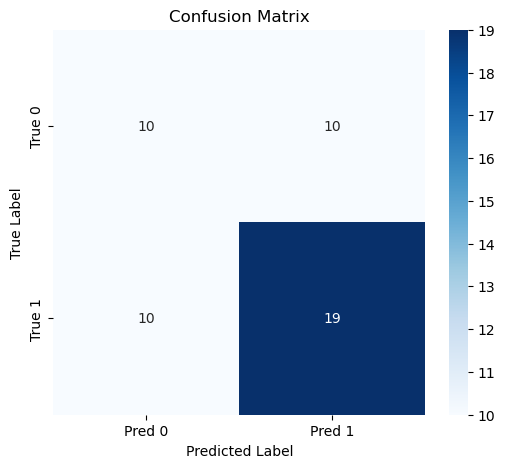

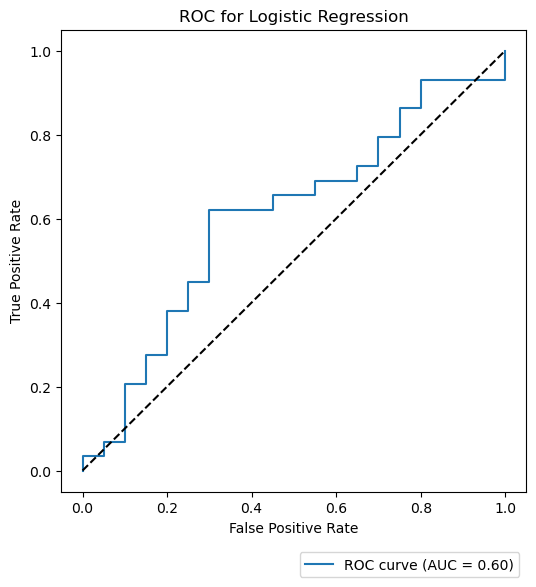

In [24]:

#no need for outputing the model's coefficent because we have 500 columns
y_prob=model.predict_proba(X_test)[:,1]
y_pred=model.predict(X_test)
print(classification_report(y_test, y_pred))
auc=roc_auc_score(y_test, y_prob)

cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=["Pred 0", "Pred 1"],
yticklabels=["True 0", "True 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix Baseline.png", bbox_inches='tight', transparent=True)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.title("ROC for Logistic Regression")

plt.show()

In [25]:
#bootstrapping F1-score
bootstrap_f1(y_pred, y_test)

F1-score 95% confidence intervals:  0.42833333333333334  -  0.7030623040752352  and a mean of:  0.5702814809548956


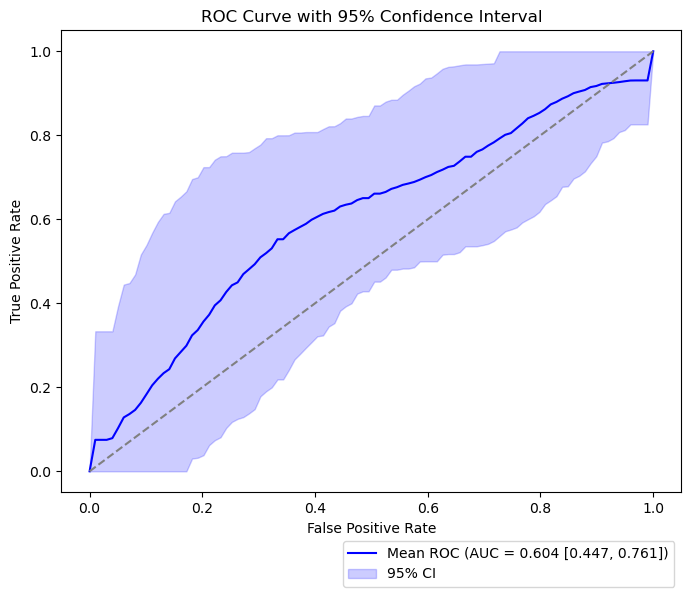

In [26]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.22), facecolor='none')
plt.savefig("Results/ROC curve Logistic Regression.png", bbox_inches='tight', transparent=True)

plt.show()

In [27]:
#feature importance of logistic regression

coef = model.coef_[0]  
coef_numerical=coef[:6]
comment_importance = np.abs(coef[-512:-256]).mean()
video_importance   = np.abs(coef[-256:]).mean()
features = df_modelling[numerical_columns].columns.to_list()
features.extend(["comment_importance", 'video_importance'])

importance = pd.DataFrame({
    "feature": features,
    "coefficient": np.concatenate([coef_numerical, [comment_importance], [video_importance]])
}).sort_values(by="coefficient", ascending=False)

print(importance)

                      feature  coefficient
6          comment_importance     0.339305
2  number_of_comments_at_date     0.285694
4       comment_sentiment_agg     0.247960
7            video_importance     0.080381
5            sentiment_tensor     0.078099
0       Closing Price($) lag1    -0.010527
1    relative difference lag1    -0.324418
3           comment_likes_agg    -0.356423


4th Best Model LGBM -> F1: 49%

In [28]:
#retrieveing best LGMB model
model=joblib.load("best_model_LGMB.joblib")

/Users/irtg/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and be

Best Result is f1 0.49310344827586206 at threshold 0.30000000000000004
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        20
           1       0.59      0.59      0.59        29

    accuracy                           0.51        49
   macro avg       0.49      0.49      0.49        49
weighted avg       0.51      0.51      0.51        49



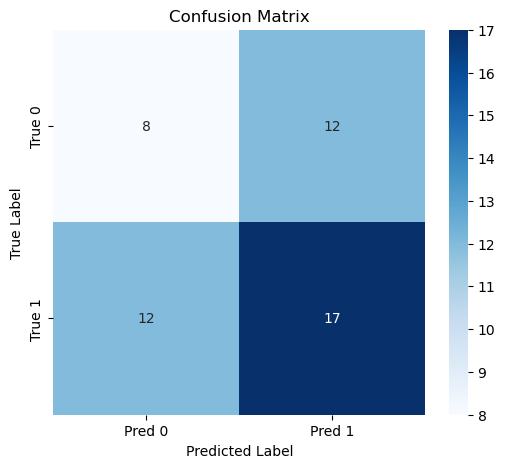

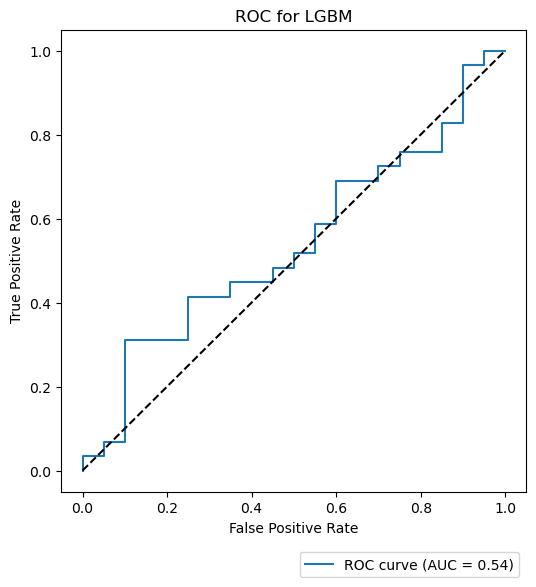

In [29]:
#making out the best threshold
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0
best_report=None
#target performance score macro avg of f1_score 
y_prob = model.predict_proba(X_val)[:,1]
for threshold in thresholds:
    y_prob_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_prob_tr, output_dict=True)
    f1=report['macro avg']['f1-score']
    f1_scores.append(report['macro avg']['f1-score'])
    

f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#testing on test data
y_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_prob > threshold).astype(int)

report=classification_report(y_test, y_pred, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")
best_cm=confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
auc=roc_auc_score(y_test, y_prob)

cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=["Pred 0", "Pred 1"],
yticklabels=["True 0", "True 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Results/Confusion Matrix LGBM.png", bbox_inches='tight', transparent=True)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
plt.title("ROC for LGBM")

plt.show()

In [30]:
#bootstrapping F1-score
bootstrap_f1(y_pred, y_test)

F1-score 95% confidence intervals:  0.3500213949507916  -  0.6287878787878788  and a mean of:  0.4905106899078014


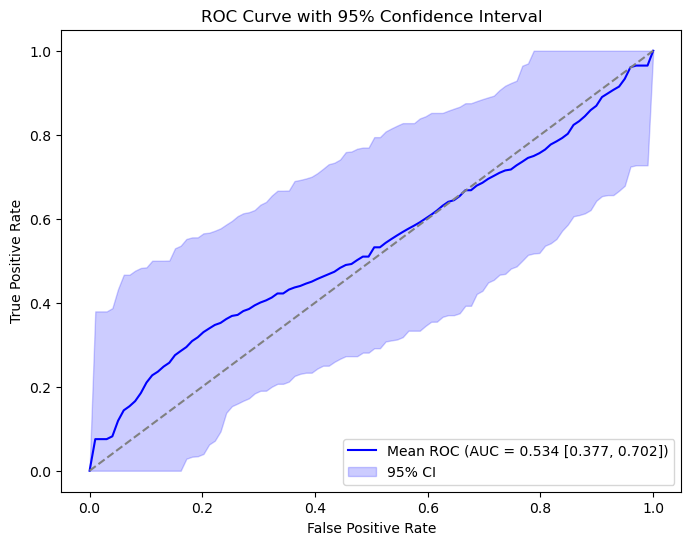

In [31]:
#confidence 
n_bootstraps = 1000
rng = np.random.RandomState(42)

# base ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# grid for interpolation
mean_fpr = np.linspace(0, 1, 100)

tprs = []
aucs = []

for i in range(n_bootstraps):
    indices = resample(range(len(y_test)), replace=True)
    
    # skip invalid samples
    if len(np.unique(y_test[indices])) < 2:
        continue
    
    y_true_sample = y_test[indices]
    y_scores_sample = y_prob[indices]
    
    fpr_i, tpr_i, _ = roc_curve(y_true_sample, y_scores_sample)
    auc_i = roc_auc_score(y_true_sample, y_scores_sample)
    
    # interpolate TPR onto common FPR grid
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    
    tprs.append(tpr_interp)
    aucs.append(auc_i)

# convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# mean and CI
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.percentile(tprs, 97.5, axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)

mean_auc = aucs.mean()
auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

# plot
plt.figure(figsize=(8, 6))

# mean ROC
plt.plot(mean_fpr, mean_tpr,
         label=f"Mean ROC (AUC = {mean_auc:.3f} [{auc_lower:.3f}, {auc_upper:.3f}])",
         color="blue")

# confidence band
plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="blue", alpha=0.2,
                 label="95% CI")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% Confidence Interval")
plt.legend(loc="lower right")
plt.savefig("Results/ROC curve LGBM.png", bbox_inches='tight', transparent=True)
plt.show()